In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
!python3 borough_complaints.py -i ~/311_2024.csv -s 2024-01-01 -e 2024-02-29 -o janfeb.csv
!python3 borough_complaints.py -i ~/311_2024.csv -s 2024-06-01 -e 2024-07-31 -o junjul.csv

In [3]:
import pandas as pd

janfeb = pd.read_csv("janfeb.csv")
junjul = pd.read_csv("junjul.csv")

totals = janfeb.groupby("complaint type")["count"].sum().sort_values(ascending=False)
top = totals.index[0]
print("Most abundant complaint type:", top)
totals.head(10)

Most abundant complaint type: HEAT/HOT WATER


complaint type
HEAT/HOT WATER          81641
Illegal Parking         79916
Noise - Residential     43602
Blocked Driveway        28608
UNSANITARY CONDITION    19208
PLUMBING                12060
PAINT/PLASTER           11725
Abandoned Vehicle       11466
Street Condition        10874
WATER LEAK               9178
Name: count, dtype: int64

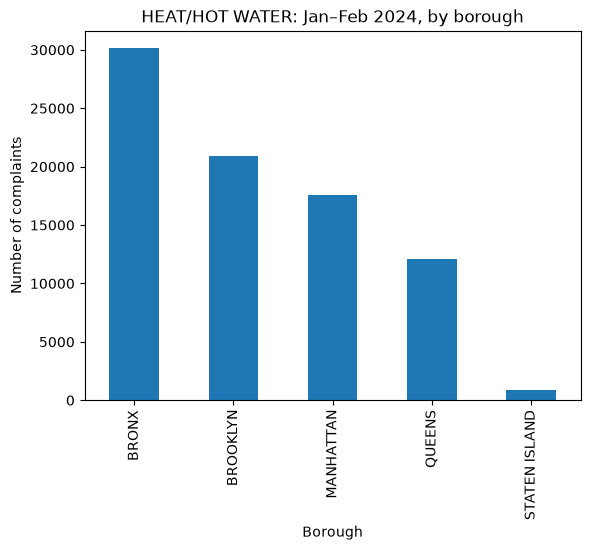

In [4]:
jf = janfeb[janfeb["complaint type"] == top].set_index("borough")["count"]
ax = jf.plot.bar(title=f"{top}: Jan–Feb 2024, by borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of complaints");

,Jan–Feb,Jun–Jul,% change
borough,,,
BRONX,30139,2227,-92.6
BROOKLYN,20915,1929,-90.8
MANHATTAN,17604,1778,-89.9
QUEENS,12117,835,-93.1
STATEN ISLAND,866,121,-86.0
TOTAL,81641,6890,-91.6


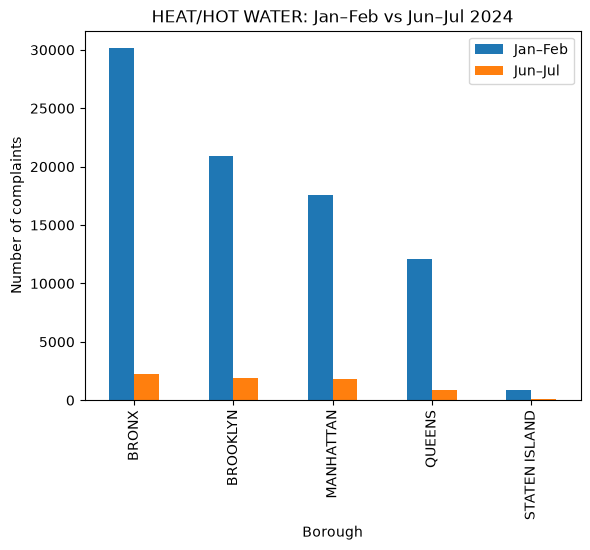

In [5]:
jj = junjul[junjul["complaint type"] == top].set_index("borough")["count"]

comparison = pd.DataFrame({"Jan–Feb": jf, "Jun–Jul": jj}).fillna(0)
ax = comparison.plot.bar(title=f"{top}: Jan–Feb vs Jun–Jul 2024")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of complaints");

comparison.loc["TOTAL"] = comparison.sum()
comparison["% change"] = (comparison["Jun–Jul"] - comparison["Jan–Feb"]) / comparison["Jan–Feb"] * 100
comparison.round(1)

In [9]:
## COMPARING THE TWO GRAPHS:
##The most abundant complaint type in Jan–Feb 2024 was HEAT/HOT WATER (81,641 complaints). 
##In Jun–Jul 2024, the same type dropped to 6,890, a decrease of about 92%, with similar drops (86–93%) in every borough. 
##This reflects seasonality: NYC's heating season runs October–May, so heat complaints peak in winter, while summer complaints are mostly about hot water. 
##The Bronx had the most complaints in both periods despite having a smaller population than Brooklyn or Queens.